1-Import Libraries

In [ ]:
#Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

#numpy=numerical calculations
#pandas=working with datasets and tabels
import numpy as np
import pandas as pd

#matplotlib=visualization
import matplotlib.pyplot as plt

#makes statistical graphs easier
import seaborn as sns

#white background and grid
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

#split the dataset into training and testing data
from sklearn.model_selection import train_test_split

#imports two preprocesssing tools
from sklearn.preprocessing import LabelEncoder, StandardScaler

#classifies algorithm
from sklearn.linear_model import LogisticRegression

#used for combined descision for trees
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

#measure how well your model perform
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

#can put any value than 42
RANDOM_STATE = 42

2-Load Dataset

In [ ]:
#save the content into google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#go this folder to find dataset
%cd "/content/drive/MyDrive/churn prediction modeling"

/content/drive/MyDrive/churn prediction modeling


In [ ]:
#read csv file
df = pd.read_csv("Churn_Modelling.csv")

#rows and columns count
print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


3-Data Cleaning

3.1-Check for Missing Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct}).sort_values("Missing Count", ascending=False)

,Missing Count,Missing %
RowNumber,0,0.0
CustomerId,0,0.0
Surname,0,0.0
CreditScore,0,0.0
Geography,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0


3.2-Check for duplicate rows

In [7]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate CustomerId:", df['CustomerId'].duplicated().sum())

Duplicate rows: 0
Duplicate CustomerId: 0


3.3-Drop irrelevant/Identifier Columns

In [ ]:
#drop unwanted columns in the dataset
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)

#display the 5 rows
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


3.4-Data types & Unique Values Check

In [ ]:
#return all column names in your dataframe
for col in df.columns:
    print(f"{col:20s} | dtype: {str(df[col].dtype):10s} | unique values: {df[col].nunique()}")

CreditScore          | dtype: int64      | unique values: 460
Geography            | dtype: object     | unique values: 3
Gender               | dtype: object     | unique values: 2
Age                  | dtype: int64      | unique values: 70
Tenure               | dtype: int64      | unique values: 11
Balance              | dtype: float64    | unique values: 6382
NumOfProducts        | dtype: int64      | unique values: 4
HasCrCard            | dtype: int64      | unique values: 2
IsActiveMember       | dtype: int64      | unique values: 2
EstimatedSalary      | dtype: float64    | unique values: 9999
Exited               | dtype: int64      | unique values: 2


3.5-Check for invalid/ Out-of-Range Values

In [10]:
print("Age range:", df['Age'].min(), "-", df['Age'].max())
print("CreditScore range:", df['CreditScore'].min(), "-", df['CreditScore'].max())
print("Balance range:", df['Balance'].min(), "-", df['Balance'].max())
print("Tenure range:", df['Tenure'].min(), "-", df['Tenure'].max())
print("NumOfProducts unique:", sorted(df['NumOfProducts'].unique()))
print("Geography unique:", df['Geography'].unique())
print("Gender unique:", df['Gender'].unique())

Age range: 18 - 92
CreditScore range: 350 - 850
Balance range: 0.0 - 250898.09
Tenure range: 0 - 10
NumOfProducts unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Geography unique: ['France' 'Spain' 'Germany']
Gender unique: ['Female' 'Male']


4-Exploratory Data Analysis (EDA)

4.1-Target Variable Distribution (Exited)

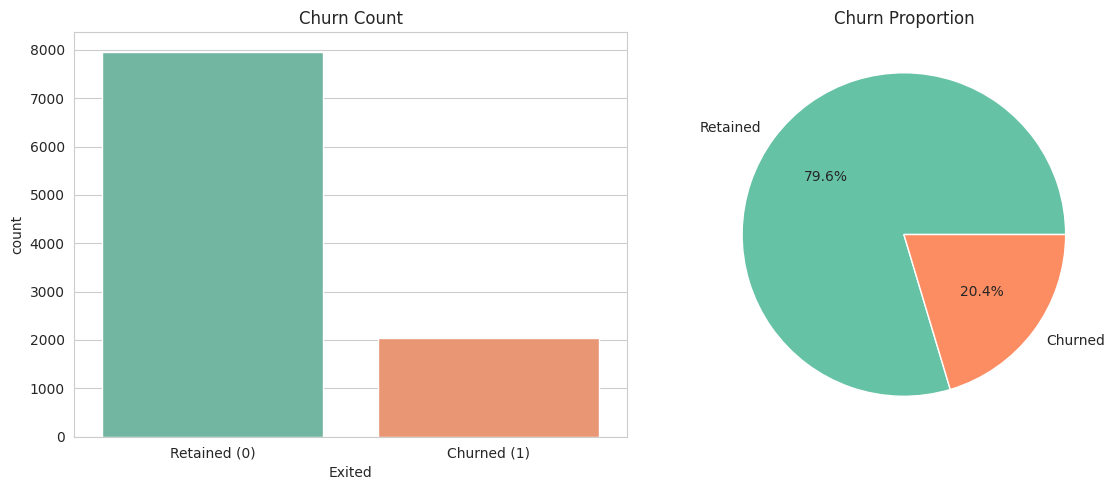

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


In [ ]:
#create two plotting areas
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

#creates countplot showing how many customers belong to each Exited category
sns.countplot(x="Exited", data=df, ax=ax[0], palette="Set2")

#set the graph title 
ax[0].set_title("Churn Count")
#change the x-axis lables
ax[0].set_xticklabels(["Retained (0)", "Churned (1)"])

#This creates a pie chart showing the percentage of customers who stayed vs churned.
#.value_counts()=Counts how many times each value appears.
#plot.pie()=Converts those counts into a pie chart.
#autopct = show percentages
#colors  = set pie chart lables
df["Exited"].value_counts().plot.pie(
    autopct="%1.1f%%", labels=["Retained", "Churned"],
    colors=sns.color_palette("Set2"), ax=ax[1]
)

#Remove the y-axis label
ax[1].set_ylabel("")

#title
ax[1].set_title("Churn Proportion")

#adjust the layout
plt.tight_layout()
plt.show()

#Instead of returning the counts, it returns the proportion of each class.
print(df["Exited"].value_counts(normalize=True))

4.2-Numerical Feature Distributions

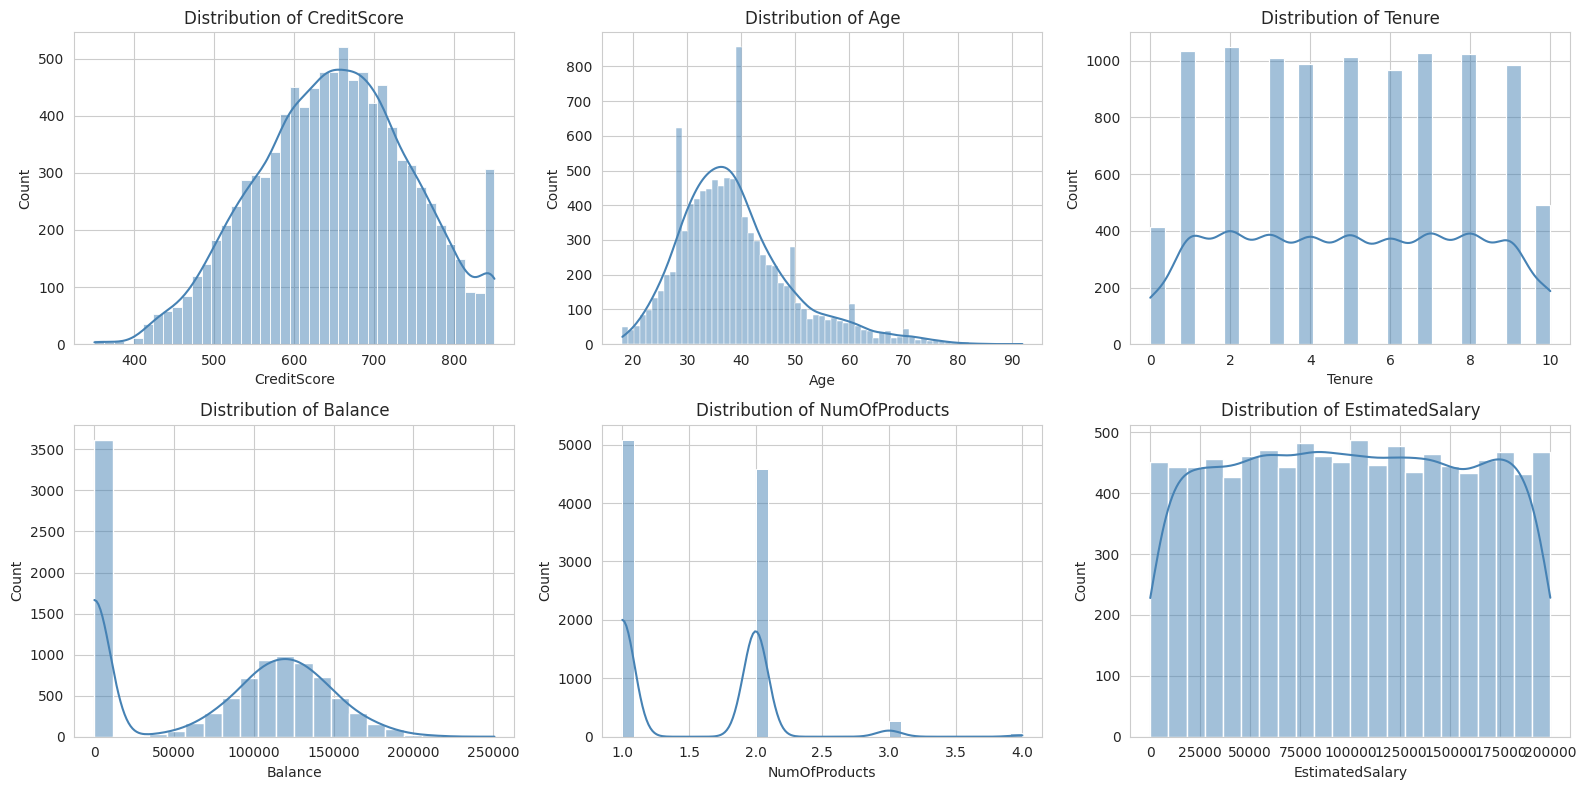

In [ ]:
#select the numerical columns
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]

#Create the plotting areas
#This creates 6 plots arranged in 2 rows and 3 columns.
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

#Flatten the axes Before flattening, axes is arranged like a 2D array
axes = axes.flatten()

#enumerate() gives you both the index and the column name.
#Kernel Density Estimate = It adds a smooth curve over the histogram to show the approximate shape of the distribution.
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")

#Automatically adjusts the spacing between the six graphs.
plt.tight_layout()
plt.show()

4.3-Categorical Features vs Churn

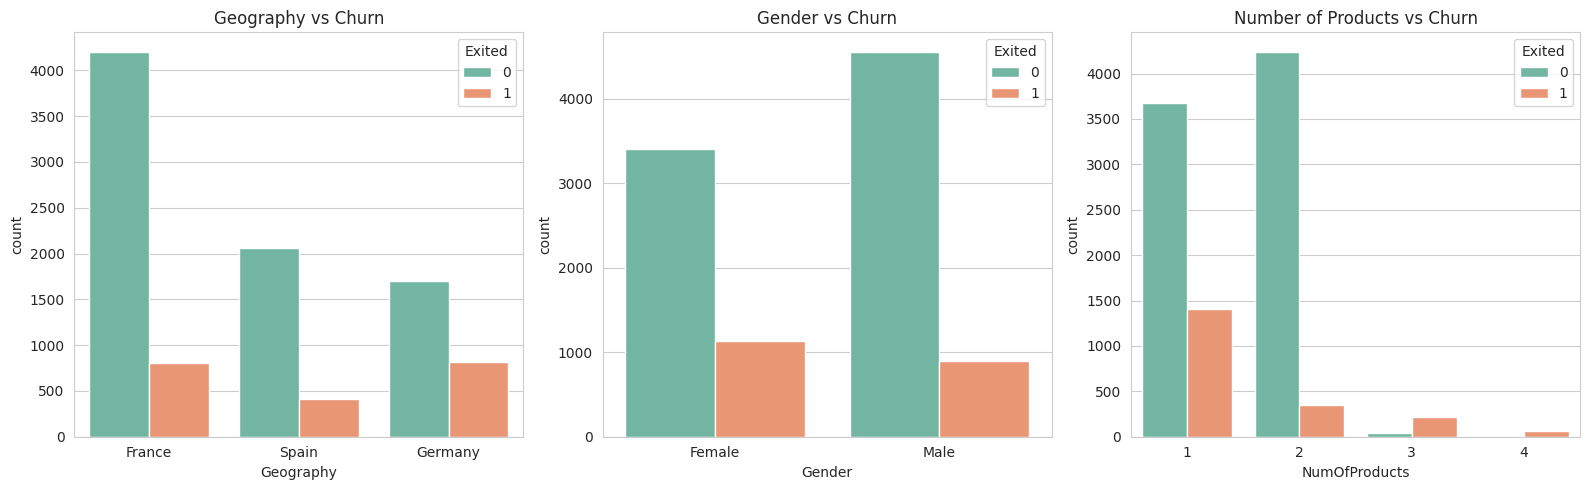

In [ ]:
#Create 3 plotting areas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#This creates the first count plot.
sns.countplot(x="Geography", hue="Exited", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Geography vs Churn")

#This creates the second count plot.
sns.countplot(x="Gender", hue="Exited", data=df, ax=axes[1], palette="Set2")
axes[1].set_title("Gender vs Churn")

#This creates the third count plot.
sns.countplot(x="NumOfProducts", hue="Exited", data=df, ax=axes[2], palette="Set2")
axes[2].set_title("Number of Products vs Churn")

plt.tight_layout()
plt.show()

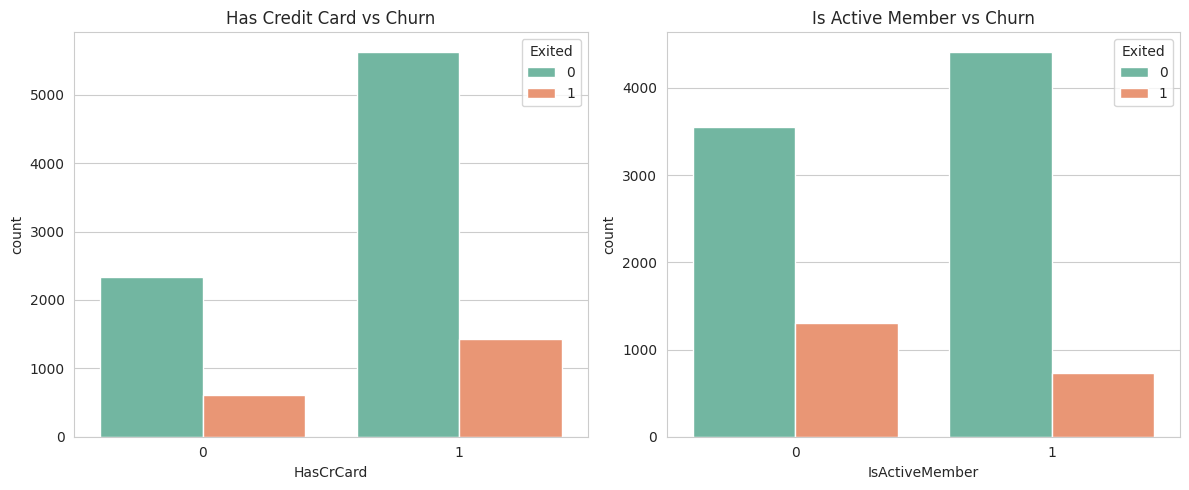

In [ ]:
#To identify patterns between customer characteristics and churn before building the machine learning models.
#Create two plotting areas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#This creates the first graph.
sns.countplot(x="HasCrCard", hue="Exited", data=df, ax=axes[0], palette="Set2")
#Title for the first graph
axes[0].set_title("Has Credit Card vs Churn")

#This creates the second graph.
sns.countplot(x="IsActiveMember", hue="Exited", data=df, ax=axes[1], palette="Set2")
#Title for the second graph
axes[1].set_title("Is Active Member vs Churn")

#adjust spacing
plt.tight_layout()
plt.show()

4.4-Numerical Features vs Churn (Boxplots)

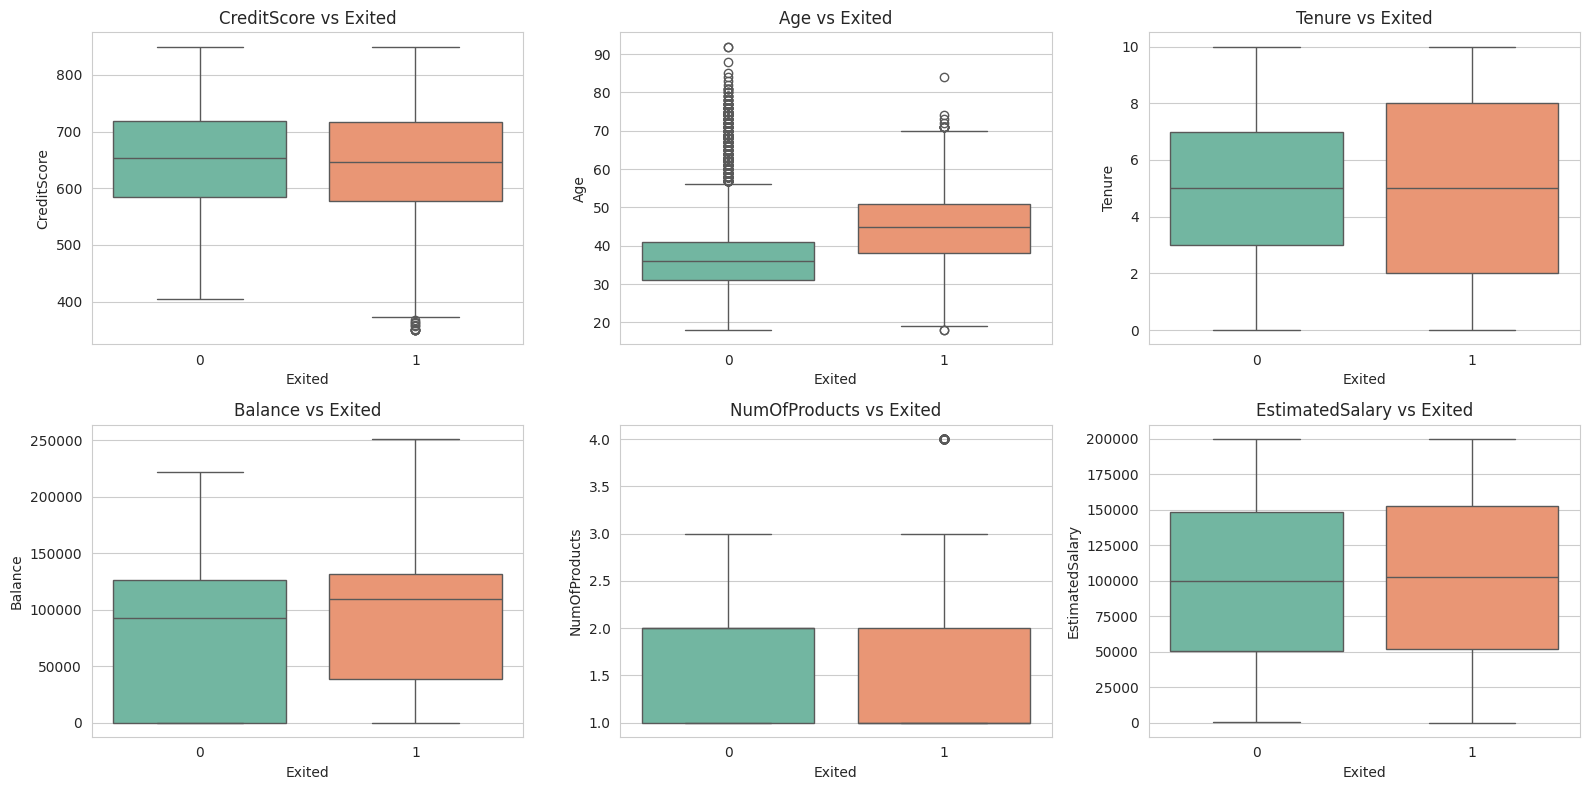

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x="Exited", y=col, data=df, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} vs Exited")
plt.tight_layout()
plt.show()

4.5-Correlation Heatmap

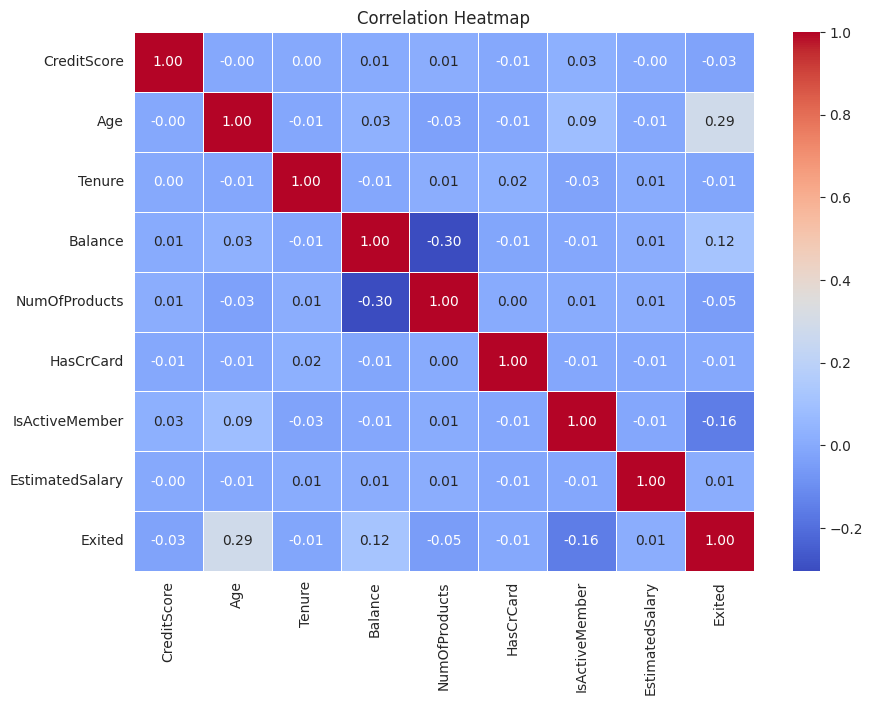

In [16]:
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

4.6-Outlier Detection (IQR method)

In [17]:
def count_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_summary = {col: count_outliers_iqr(df[col]) for col in num_cols}
pd.DataFrame.from_dict(outlier_summary, orient="index", columns=["Outlier Count"])

,Outlier Count
CreditScore,15
Age,359
Tenure,0
Balance,0
NumOfProducts,60
EstimatedSalary,0


> `CreditScore` and `Age` show some outliers via IQR, but they are realistic (valid credit scores / ages), so we retain them rather than removing — tree-based and boosting models are robust to such outliers, and removing real customer data could bias the churn signal.

Preprocessing

5.1-Encode Categorical Variables

- `Gender` → Label Encoding (binary)
- `Geography` → One-Hot Encoding (nominal, >2 categories)

In [18]:
df_model = df.copy()

le = LabelEncoder()
df_model["Gender"] = le.fit_transform(df_model["Gender"])  # Female=0, Male=1

df_model = pd.get_dummies(df_model, columns=["Geography"], drop_first=True)

df_model.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


5.2-Feature / Target Split

In [19]:
X = df_model.drop(columns=["Exited"])
y = df_model["Exited"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
X.columns.tolist()

Features shape: (10000, 11)
Target shape: (10000,)


['CreditScore',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Geography_Germany',
 'Geography_Spain']

5.3-Train-Test Split (Stratified)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train churn rate:", y_train.mean().round(3))
print("Test churn rate :", y_test.mean().round(3))

Train shape: (8000, 11)
Test shape : (2000, 11)
Train churn rate: 0.204
Test churn rate : 0.204


5.4-Feature Scaling

Scaling is required for Logistic Regression and the ANN. Tree/boosting models (RF, Extra Trees, XGBoost, LightGBM, CatBoost) don't need it, but using the scaled version doesn't hurt them, so we keep both versions available.

In [21]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
2151,1.058568,0.907507,1.715086,0.684723,-1.226059,-0.910256,0.641042,-1.030206,1.042084,-0.578313,-0.577735
8392,0.913626,0.907507,-0.659935,-0.696202,0.413288,-0.910256,0.641042,-1.030206,-0.623556,1.729169,-0.577735
5006,1.079274,-1.101919,-0.184931,-1.731895,0.601687,0.808830,0.641042,0.970680,0.308128,1.729169,-0.577735
4117,-0.929207,0.907507,-0.184931,-0.005739,-1.226059,0.808830,0.641042,-1.030206,-0.290199,-0.578313,-0.577735
7182,0.427035,0.907507,0.955079,0.339492,0.548318,0.808830,-1.559960,0.970680,0.135042,1.729169,-0.577735


5.5-Class Imbalance Check

Churn (~20%) is moderately imbalanced. We keep `class_weight='balanced'` / `scale_pos_weight` options available per-model rather than oversampling, to preserve the real-world distribution.

In [22]:
print(y_train.value_counts())
print("Imbalance ratio:", round(y_train.value_counts()[0] / y_train.value_counts()[1], 2), ": 1")

Exited
0    6370
1    1630
Name: count, dtype: int64
Imbalance ratio: 3.91 : 1


6-Modeling

6.1-Evaluation Helper Function

A single reusable function to train, predict, score, and store results for every model so all 9 models are evaluated identically.

In [23]:
results = []

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, proba_from=None):
    """
    Fit `model`, predict on X_te, compute metrics, store & print them.
    proba_from: optional callable(model, X_te) -> probability array,
                for models (e.g. TabNet/Keras) with a non-sklearn predict_proba signature.
    """
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_pred = np.array(y_pred).astype(int).ravel()

    if proba_from is not None:
        y_proba = proba_from(model, X_te)
    else:
        y_proba = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_proba)

    results.append({
        "Model": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1-Score": f1, "ROC-AUC": auc
    })

    print(f"--- {name} ---")
    print(classification_report(y_te, y_pred, target_names=["Retained", "Churned"]))
    print("ROC-AUC:", round(auc, 4))

    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_te, y_pred), annot=True, fmt="d", cmap="Blues",
                xticklabels=["Retained", "Churned"], yticklabels=["Retained", "Churned"])
    plt.title(f"{name} — Confusion Matrix")
    plt.ylabel("Actual"); plt.xlabel("Predicted")
    plt.show()

    return model

6.2-Logistic Regression

--- Logistic Regression ---
              precision    recall  f1-score   support

    Retained       0.90      0.72      0.80      1593
     Churned       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000

ROC-AUC: 0.7771


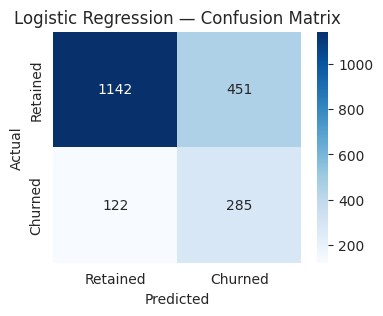

In [24]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
log_reg = evaluate_model("Logistic Regression", log_reg, X_train_scaled, y_train, X_test_scaled, y_test)

6.3-Random Forest

--- Random Forest ---
              precision    recall  f1-score   support

    Retained       0.91      0.89      0.90      1593
     Churned       0.60      0.65      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.84      0.84      0.84      2000

ROC-AUC: 0.8629


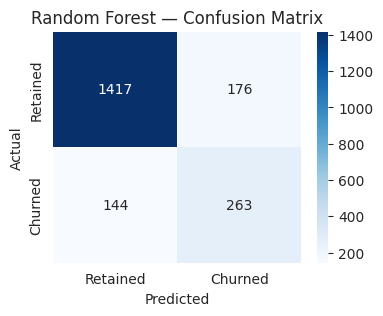

In [25]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
rf = evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test)

6.4-Extra Trees

--- Extra Trees ---
              precision    recall  f1-score   support

    Retained       0.92      0.82      0.87      1593
     Churned       0.51      0.71      0.59       407

    accuracy                           0.80      2000
   macro avg       0.71      0.77      0.73      2000
weighted avg       0.83      0.80      0.81      2000

ROC-AUC: 0.8544


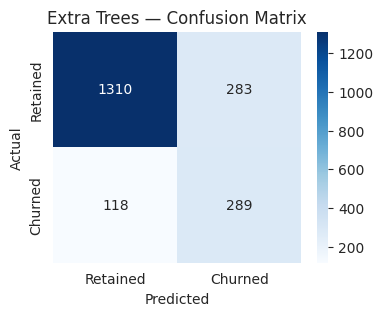

In [26]:
et= ExtraTreesClassifier(
    n_estimators=300, max_depth=10, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
et = evaluate_model("Extra Trees", et, X_train, y_train, X_test, y_test)

6.5-XGBoost

--- XGBoost ---
              precision    recall  f1-score   support

    Retained       0.92      0.83      0.88      1593
     Churned       0.53      0.72      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000

ROC-AUC: 0.8594


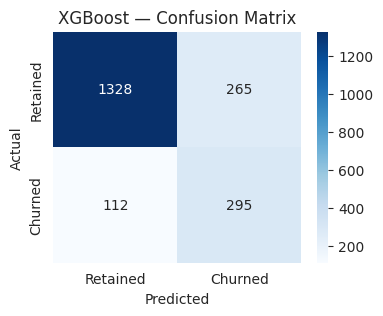

In [27]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
)
xgb = evaluate_model("XGBoost", xgb, X_train, y_train, X_test, y_test)

6.6-LightGBM

--- LightGBM ---
              precision    recall  f1-score   support

    Retained       0.92      0.85      0.88      1593
     Churned       0.55      0.70      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.77      0.75      2000
weighted avg       0.84      0.82      0.83      2000

ROC-AUC: 0.8588


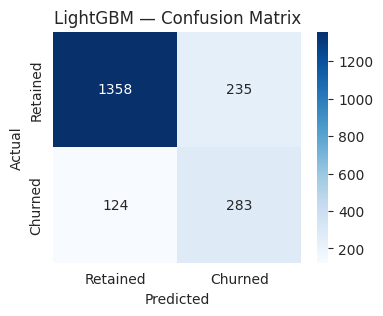

In [28]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=300, max_depth=-1, learning_rate=0.05,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
lgbm = evaluate_model("LightGBM", lgbm, X_train, y_train, X_test, y_test)

6.7-CatBoost

In [29]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00


--- CatBoost ---
              precision    recall  f1-score   support

    Retained       0.92      0.85      0.88      1593
     Churned       0.54      0.72      0.62       407

    accuracy                           0.82      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.85      0.82      0.83      2000

ROC-AUC: 0.8576


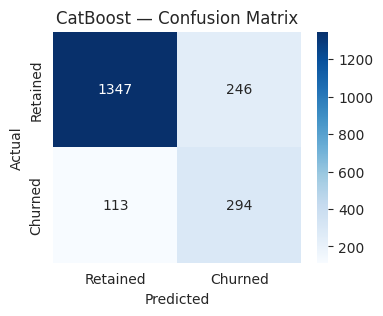

In [30]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=500, depth=6, learning_rate=0.05,
    auto_class_weights="Balanced",
    random_state=RANDOM_STATE, verbose=0
)
catboost_model = evaluate_model("CatBoost", catboost_model, X_train, y_train, X_test, y_test)

6.8-TabNet

`TabNetClassifier` uses PyTorch under the hood and expects **numpy arrays**, and `.fit()` has a different signature (needs `eval_set`), so it's wired in separately rather than through the generic sklearn-style helper.

In [31]:
!pip install -q pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.4 MB/s eta 0:00:00


In [32]:
import pytorch_tabnet

print("TabNet installed successfully!")

TabNet installed successfully!


In [33]:
import sys
!{sys.executable} -m pip install pytorch-tabnet

In [34]:
from pytorch_tabnet.tab_model import TabNetClassifier

print("TabNet import successful!")

TabNet import successful!


In [35]:
import numpy as np
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Random seed
RANDOM_STATE = 42

# Convert data to NumPy arrays
X_train_np = X_train_scaled.values.astype(np.float32)
X_test_np = X_test_scaled.values.astype(np.float32)

y_train_np = y_train.values.astype(np.int64)
y_test_np = y_test.values.astype(np.int64)

# Create TabNet model
tabnet = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=4,
    gamma=1.3,
    seed=RANDOM_STATE,
    verbose=0
)

# Train TabNet
tabnet.fit(
    X_train=X_train_np,
    y_train=y_train_np,
    eval_set=[(X_test_np, y_test_np)],
    eval_metric=["auc"],
    max_epochs=100,
    patience=15,
    batch_size=256,
    virtual_batch_size=128
)

# Predictions
y_pred_tabnet = tabnet.predict(X_test_np)
y_proba_tabnet = tabnet.predict_proba(X_test_np)[:, 1]

# Store results
results.append({
    "Model": "TabNet",
    "Accuracy": accuracy_score(y_test_np, y_pred_tabnet),
    "Precision": precision_score(y_test_np, y_pred_tabnet),
    "Recall": recall_score(y_test_np, y_pred_tabnet),
    "F1-Score": f1_score(y_test_np, y_pred_tabnet),
    "ROC-AUC": roc_auc_score(y_test_np, y_proba_tabnet),
})

# Classification report
print("TabNet Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test_np,
        y_pred_tabnet,
        target_names=["Retained", "Churned"]
    )
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test_np, y_proba_tabnet), 4)
)


Early stopping occurred at epoch 63 with best_epoch = 48 and best_val_0_auc = 0.86976
TabNet Classification Report
              precision    recall  f1-score   support

    Retained       0.88      0.97      0.92      1593
     Churned       0.80      0.47      0.59       407

    accuracy                           0.87      2000
   macro avg       0.84      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000

ROC-AUC: 0.8698


6.9-TabPFN

TabPFN is a pretrained transformer for tabular data — there is (almost) no hyperparameter training loop, it just does a forward pass. The public TabPFN classifier is optimized for **small-to-mid data** (originally ≤1,000 rows / 100 features for v1; the newer v2/"TabPFN-3" style estimator handles up to ~10,000 rows and 500 features but gets slow/memory-heavy at the top end). Since we have 8,000 training rows, we **subsample the training set** for speed — feel free to remove the subsampling if your TabPFN build/hardware supports the full set.

In [36]:
import os
import requests

print("Token exists:", bool(os.environ.get("TABPFN_TOKEN")))

try:
    r = requests.get("https://ux.priorlabs.ai", timeout=15)
    print("TabPFN server status:", r.status_code)
    print("Connection: OK")
except Exception as e:
    print("Connection FAILED")
    print(type(e).__name__, e)

Token exists: False
TabPFN server status: 200
Connection: OK


In [37]:
import os

os.environ.pop("TABPFN_TOKEN", None)

os.environ["TABPFN_TOKEN"] = "tabpfn_sk_bD-e…ljVk"

In [38]:
!pip install tabpfn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 748.1/748.1 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 8.5 MB/s eta 0:00:00


In [39]:
from tabpfn import TabPFNClassifier

tabpfn = TabPFNClassifier(
    random_state=42
)

print("Model created")

Model created


In [40]:
import os

os.environ.pop("TABPFN_TOKEN", None)

print("Old token removed")

Old token removed


In [41]:
import os

TOKEN = "tabpfn_sk_rqa_SZn0WwQeyP2B7pDKJHP1JSeIbZj7RP6qP3KGPOY"

os.environ["TABPFN_TOKEN"] = TOKEN

print("Token loaded:", bool(os.environ["TABPFN_TOKEN"]))

Token loaded: True


In [42]:
token = os.environ["TABPFN_TOKEN"]

print("Contains ellipsis:", "…" in token)
print("Contains three dots:", "..." in token)
print("Contains spaces:", any(c.isspace() for c in token))
print("ASCII only:", all(ord(c) < 128 for c in token))
print("Token length:", len(token))

Contains ellipsis: False
Contains three dots: False
Contains spaces: False
ASCII only: True
Token length: 53


In [43]:
from tabpfn import TabPFNClassifier

tabpfn = TabPFNClassifier(
    random_state=42
)

print("TabPFN initialized successfully!")

TabPFN initialized successfully!


tabpfn-v3-classifier-v3_default.ckpt: reconstructing file:   0%|          |  0.00B /  213MB            

tabpfn-v3-classifier-v3_default.ckpt: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

--- TabPFN ---
              precision    recall  f1-score   support

    Retained       0.88      0.96      0.92      1593
     Churned       0.78      0.51      0.61       407

    accuracy                           0.87      2000
   macro avg       0.83      0.74      0.77      2000
weighted avg       0.86      0.87      0.86      2000

ROC-AUC: 0.8788


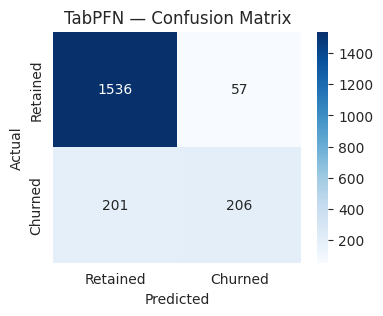

In [44]:
tabpfn = evaluate_model(
    "TabPFN",
    tabpfn,
    X_train,
    y_train,
    X_test,
    y_test
)

6.10-Artificial Neural Network (ANN)

A simple feed-forward network (Keras/TensorFlow) with dropout for regularization, trained on the scaled features.

In [45]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(RANDOM_STATE)

ann = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

ann.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy", keras.metrics.AUC(name="auc")])

class_weight = {0: 1.0, 1: (y_train == 0).sum() / (y_train == 1).sum()}

early_stop = keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=15, restore_best_weights=True)

history = ann.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100, batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=0
)

y_proba_ann = ann.predict(X_test_scaled).ravel()
y_pred_ann = (y_proba_ann >= 0.5).astype(int)

results.append({
    "Model": "ANN",
    "Accuracy": accuracy_score(y_test, y_pred_ann),
    "Precision": precision_score(y_test, y_pred_ann),
    "Recall": recall_score(y_test, y_pred_ann),
    "F1-Score": f1_score(y_test, y_pred_ann),
    "ROC-AUC": roc_auc_score(y_test, y_proba_ann),
})

print(classification_report(y_test, y_pred_ann, target_names=["Retained", "Churned"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_ann), 4))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

    Retained       0.93      0.79      0.85      1593
     Churned       0.48      0.77      0.59       407

    accuracy                           0.78      2000
   macro avg       0.70      0.78      0.72      2000
weighted avg       0.84      0.78      0.80      2000

ROC-AUC: 0.8603


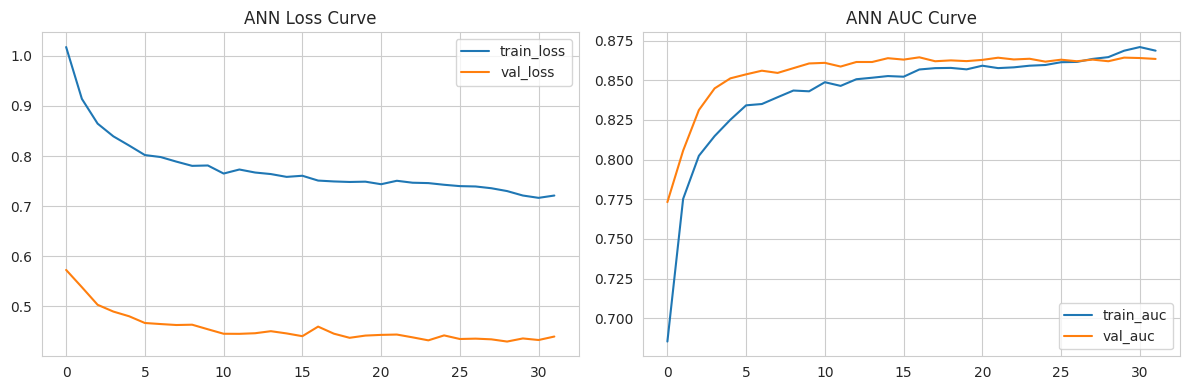

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history["loss"], label="train_loss")
ax[0].plot(history.history["val_loss"], label="val_loss")
ax[0].set_title("ANN Loss Curve"); ax[0].legend()

ax[1].plot(history.history["auc"], label="train_auc")
ax[1].plot(history.history["val_auc"], label="val_auc")
ax[1].set_title("ANN AUC Curve"); ax[1].legend()
plt.tight_layout()
plt.show()

 7.-Model Comparison

7.1-Results Table

In [47]:
results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,TabPFN,0.8710,0.783270,0.506143,0.614925,0.878754
1,TabNet,0.8680,0.801688,0.466830,0.590062,0.869760
2,Random Forest,0.8400,0.599089,0.646192,0.621749,0.862948
3,ANN,0.7830,0.479326,0.769042,0.590566,0.860312
4,XGBoost,0.8115,0.526786,0.724816,0.610134,0.859433
5,LightGBM,0.8205,0.546332,0.695332,0.611892,0.858834
6,CatBoost,0.8205,0.544444,0.722359,0.620908,0.857552
7,Extra Trees,0.7995,0.505245,0.710074,0.590398,0.854435
8,Logistic Regression,0.7135,0.387228,0.700246,0.498688,0.777138


7.2-Metric Comparison Bar Chart

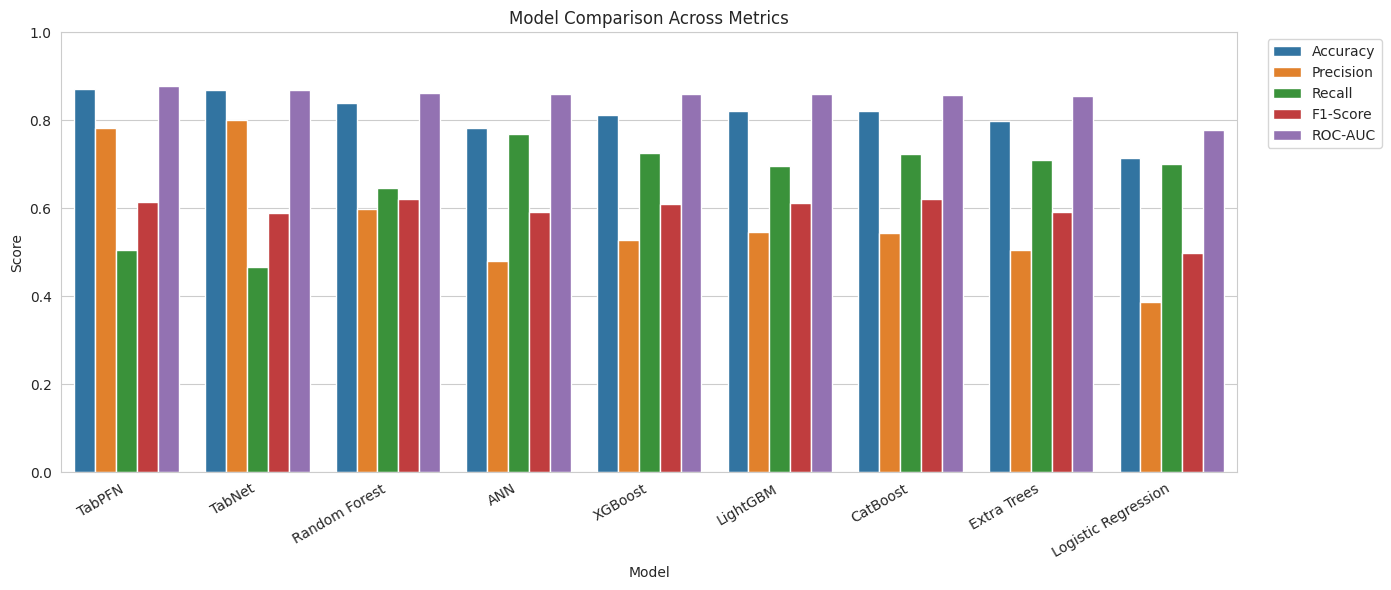

In [48]:
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(14, 6))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")
plt.xticks(rotation=30, ha="right")
plt.title("Model Comparison Across Metrics")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

7.3-ROC-AUC Ranking

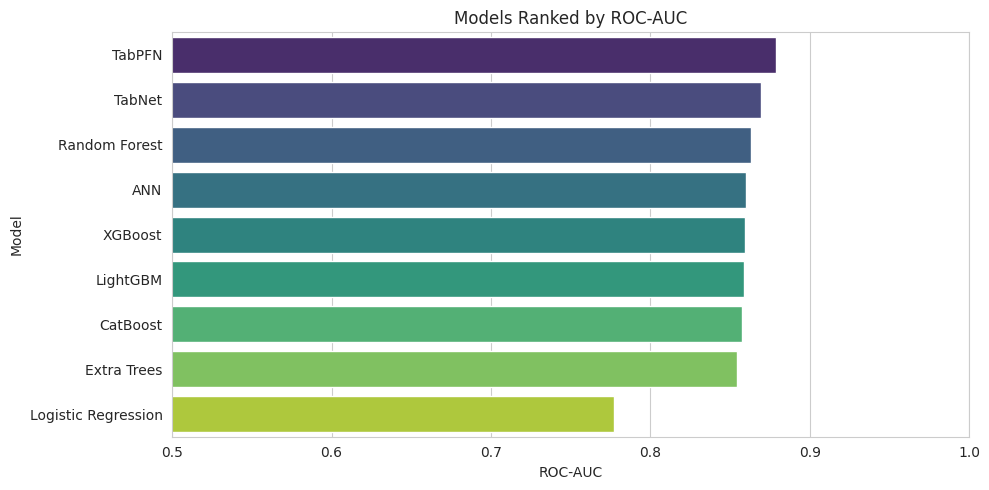

Best model: TabPFN | ROC-AUC: 0.8788


In [49]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="ROC-AUC", y="Model", palette="viridis")
plt.title("Models Ranked by ROC-AUC")
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

print("Best model:", results_df.iloc[0]["Model"], "| ROC-AUC:", round(results_df.iloc[0]["ROC-AUC"], 4))

7.4-Accuracy Comparison (All 9 Models)

In [50]:
accuracy_df = results_df[["Model", "Accuracy"]].sort_values("Accuracy", ascending=False).reset_index(drop=True)
accuracy_df["Accuracy %"] = (accuracy_df["Accuracy"] * 100).round(2)
accuracy_df

,Model,Accuracy,Accuracy %
0,TabPFN,0.8710,87.10
1,TabNet,0.8680,86.80
2,Random Forest,0.8400,84.00
3,CatBoost,0.8205,82.05
4,LightGBM,0.8205,82.05
5,XGBoost,0.8115,81.15
6,Extra Trees,0.7995,79.95
7,ANN,0.7830,78.30
8,Logistic Regression,0.7135,71.35


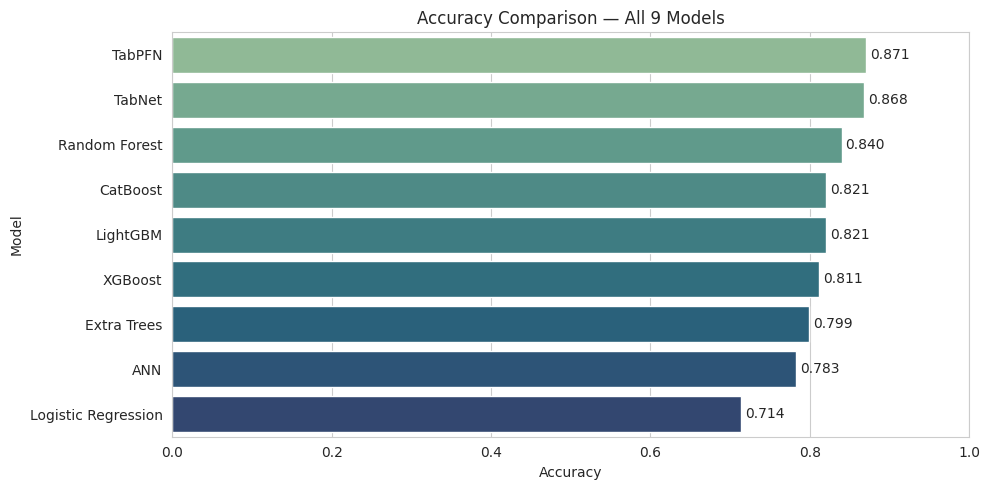

Highest accuracy: TabPFN -> 87.1 %
Lowest accuracy : Logistic Regression -> 71.35 %


In [51]:
plt.figure(figsize=(10, 5))
bars = sns.barplot(data=accuracy_df, x="Accuracy", y="Model", palette="crest")
for i, v in enumerate(accuracy_df["Accuracy"]):
    bars.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.xlim(0, 1)
plt.title("Accuracy Comparison — All 9 Models")
plt.tight_layout()
plt.show()

print("Highest accuracy:", accuracy_df.iloc[0]["Model"], "->", accuracy_df.iloc[0]["Accuracy %"], "%")
print("Lowest accuracy :", accuracy_df.iloc[-1]["Model"], "->", accuracy_df.iloc[-1]["Accuracy %"], "%")

7.5-ROC Curves — All Models Overlaid

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


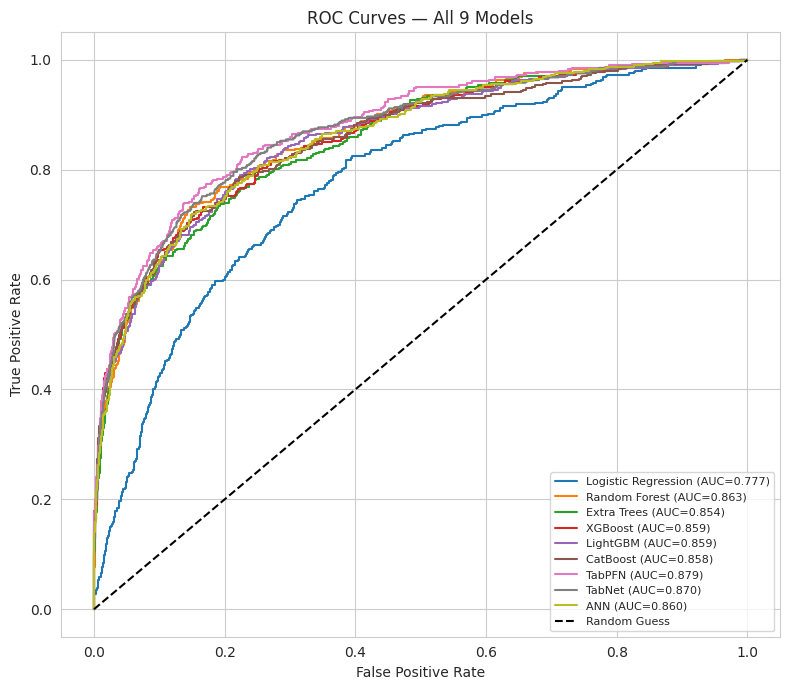

In [52]:
plt.figure(figsize=(8, 7))

roc_sources = {
    "Logistic Regression": (log_reg, X_test_scaled),
    "Random Forest": (rf, X_test),
    "Extra Trees": (et, X_test),
    "XGBoost": (xgb, X_test),
    "LightGBM": (lgbm, X_test),
    "CatBoost": (catboost_model, X_test),
    "TabPFN": (tabpfn, X_test),
}

for name, (model, X_te) in roc_sources.items():
    proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")

# TabNet
proba_tn = tabnet.predict_proba(X_test_scaled.values.astype(np.float32))[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba_tn)
plt.plot(fpr, tpr, label=f"TabNet (AUC={roc_auc_score(y_test, proba_tn):.3f})")

# ANN
proba_ann = ann.predict(X_test_scaled).ravel()
fpr, tpr, _ = roc_curve(y_test, proba_ann)
plt.plot(fpr, tpr, label=f"ANN (AUC={roc_auc_score(y_test, proba_ann):.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All 9 Models")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

8-Model Testing

This section is for **testing the trained models** — both re-confirming performance on the held-out test set through one unified function, and running predictions on brand-new, never-before-seen customer records (the real "deployment-style" test).

8.1-Collect All Trained Models

In [53]:
trained_models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "Extra Trees": et,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": catboost_model,
    "TabNet": tabnet,
    "TabPFN": tabpfn,
    "ANN": ann,
}
print("Models ready for testing:", list(trained_models.keys()))

Models ready for testing: ['Logistic Regression', 'Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM', 'CatBoost', 'TabNet', 'TabPFN', 'ANN']


Save Models

In [61]:
import os, joblib

os.makedirs("saved_models", exist_ok=True)

joblib.dump(log_reg, "saved_models/logistic_regression.pkl")
joblib.dump(rf, "saved_models/random_forest.pkl")
joblib.dump(et, "saved_models/extra_trees.pkl")
joblib.dump(xgb, "saved_models/xgboost.pkl")
joblib.dump(lgbm, "saved_models/lightgbm.pkl")
catboost_model.save_model("saved_models/catboost.cbm")
tabnet.save_model("saved_models/tabnet")               # writes tabnet.zip
joblib.dump(tabpfn, "saved_models/tabpfn.pkl")          # pretrained, no real "training" saved
ann.save("saved_models/ann.keras")

joblib.dump(scaler, "saved_models/scaler.pkl")
joblib.dump(le, "saved_models/gender_label_encoder.pkl")
joblib.dump(list(X.columns), "saved_models/feature_columns.pkl")

model_comparison = pd.DataFrame(results)

model_comparison.to_csv(
    "saved_models/model_comparison.csv",
    index=False
)

Successfully saved model at saved_models/tabnet.zip


NameError: name 'model_comparison' is not defined

Reload models

In [55]:
from catboost import CatBoostClassifier as _CatBoostClassifier
from pytorch_tabnet.tab_model import TabNetClassifier as _TabNetClassifier
from tensorflow import keras as _keras

loaded_log_reg = joblib.load("saved_models/logistic_regression.pkl")
loaded_rf = joblib.load("saved_models/random_forest.pkl")
loaded_et = joblib.load("saved_models/extra_trees.pkl")
loaded_xgb = joblib.load("saved_models/xgboost.pkl")
loaded_lgbm = joblib.load("saved_models/lightgbm.pkl")

loaded_catboost = _CatBoostClassifier()
loaded_catboost.load_model("saved_models/catboost.cbm")

loaded_tabnet = _TabNetClassifier()
loaded_tabnet.load_model("saved_models/tabnet.zip")

loaded_tabpfn = joblib.load("saved_models/tabpfn.pkl")
loaded_ann = _keras.models.load_model("saved_models/ann.keras")

loaded_scaler = joblib.load("saved_models/scaler.pkl")
loaded_le = joblib.load("saved_models/gender_label_encoder.pkl")
loaded_feature_columns = joblib.load("saved_models/feature_columns.pkl")

print("Reload check — Logistic Regression accuracy:",
      round(accuracy_score(y_test, loaded_log_reg.predict(X_test_scaled)), 4))
print("Reload check — CatBoost accuracy:",
      round(accuracy_score(y_test, loaded_catboost.predict(X_test).astype(int)), 4))
print("(Matches Section 6/7 results above -> saved models are valid.)")

Reload check — Logistic Regression accuracy: 0.7135
Reload check — CatBoost accuracy: 0.8205
(Matches Section 6/7 results above -> saved models are valid.)


Unified testing

In [56]:
def test_all_models(X_raw, X_scaled, y_true, model_dict=trained_models):
    """Run every trained model on the given data and return a metrics comparison table."""
    rows = []
    for name, model in model_dict.items():
        if name == "Logistic Regression":
            proba = model.predict_proba(X_scaled)[:, 1]
        elif name == "TabNet":
            proba = model.predict_proba(X_scaled.values.astype(np.float32))[:, 1]
        elif name == "ANN":
            proba = model.predict(X_scaled).ravel()
        else:  # RF, Extra Trees, XGBoost, LightGBM, CatBoost, TabPFN
            proba = model.predict_proba(X_raw)[:, 1]

        pred = (proba >= 0.5).astype(int)

        rows.append({
            "Model": name,
            "Accuracy": accuracy_score(y_true, pred),
            "Precision": precision_score(y_true, pred),
            "Recall": recall_score(y_true, pred),
            "F1-Score": f1_score(y_true, pred),
            "ROC-AUC": roc_auc_score(y_true, proba),
        })
    return pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)


# Test on the held-out test set
test_report = test_all_models(X_test, X_test_scaled, y_test)
test_report

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,TabPFN,0.8710,0.783270,0.506143,0.614925,0.878754
1,TabNet,0.8680,0.801688,0.466830,0.590062,0.869760
2,Random Forest,0.8400,0.599089,0.646192,0.621749,0.862948
3,CatBoost,0.8205,0.544444,0.722359,0.620908,0.857552
4,LightGBM,0.8205,0.546332,0.695332,0.611892,0.858834
5,XGBoost,0.8115,0.526786,0.724816,0.610134,0.859433
6,Extra Trees,0.7995,0.505245,0.710074,0.590398,0.854435
7,ANN,0.7830,0.479326,0.769042,0.590566,0.860312
8,Logistic Regression,0.7135,0.387228,0.700246,0.498688,0.777138


### 8.5 Testing on Brand-New / Unseen Customer Data

Simulates real deployment: a few hand-crafted customer records the models have never seen, run through the exact same preprocessing pipeline (encode → align columns → scale) used during training, then scored by all 9 models.

In [57]:
# Example new/unseen customers (edit these freely to test your own scenarios)
new_customers = pd.DataFrame([
    {"CreditScore": 619, "Geography": "France",  "Gender": "Female", "Age": 42, "Tenure": 2,
     "Balance": 0.0,      "NumOfProducts": 1, "HasCrCard": 1, "IsActiveMember": 1, "EstimatedSalary": 101348.88},
    {"CreditScore": 502, "Geography": "France",  "Gender": "Female", "Age": 42, "Tenure": 8,
     "Balance": 159660.80,"NumOfProducts": 3, "HasCrCard": 1, "IsActiveMember": 0, "EstimatedSalary": 113931.57},
    {"CreditScore": 850, "Geography": "Spain",   "Gender": "Male",   "Age": 43, "Tenure": 2,
     "Balance": 125510.82,"NumOfProducts": 1, "HasCrCard": 1, "IsActiveMember": 1, "EstimatedSalary": 79084.10},
    {"CreditScore": 645, "Geography": "Germany", "Gender": "Male",   "Age": 44, "Tenure": 8,
     "Balance": 113755.78,"NumOfProducts": 2, "HasCrCard": 1, "IsActiveMember": 0, "EstimatedSalary": 149756.71},
])
new_customers

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,502,France,Female,42,8,159660.80,3,1,0,113931.57
2,850,Spain,Male,43,2,125510.82,1,1,1,79084.10
3,645,Germany,Male,44,8,113755.78,2,1,0,149756.71


In [58]:
def preprocess_new_data(new_df, label_encoder=le, feature_columns=X.columns, scaler_obj=scaler):
    """Apply the exact same encoding/column-alignment/scaling pipeline used on the training data."""
    processed = new_df.copy()
    processed["Gender"] = label_encoder.transform(processed["Gender"])
    processed = pd.get_dummies(processed, columns=["Geography"], drop_first=True)

    # Ensure all training columns exist (e.g. Geography_Germany / Geography_Spain), fill missing with 0
    for col in feature_columns:
        if col not in processed.columns:
            processed[col] = 0
    processed = processed[feature_columns]  # exact column order as training

    processed_scaled = pd.DataFrame(
        scaler_obj.transform(processed), columns=processed.columns, index=processed.index
    )
    return processed, processed_scaled


new_raw, new_scaled = preprocess_new_data(new_customers)
new_raw

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,False,False
1,502,0,42,8,159660.80,3,1,0,113931.57,False,False
2,850,1,43,2,125510.82,1,1,1,79084.10,False,True
3,645,1,44,8,113755.78,2,1,0,149756.71,True,False


In [59]:
def predict_new_customers(X_raw, X_scaled, model_dict=trained_models, threshold=0.5):
    """Return churn probability & predicted label from every model for each new customer."""
    output = pd.DataFrame(index=X_raw.index)
    for name, model in model_dict.items():
        if name == "Logistic Regression":
            proba = model.predict_proba(X_scaled)[:, 1]
        elif name == "TabNet":
            proba = model.predict_proba(X_scaled.values.astype(np.float32))[:, 1]
        elif name == "ANN":
            proba = model.predict(X_scaled).ravel()
        else:
            proba = model.predict_proba(X_raw)[:, 1]
        output[f"{name} (Prob)"] = proba.round(3)
        output[f"{name} (Pred)"] = (proba >= threshold).astype(int)
    return output


predictions = predict_new_customers(new_raw, new_scaled)
predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step


,Logistic Regression (Prob),Logistic Regression (Pred),Random Forest (Prob),Random Forest (Pred),Extra Trees (Prob),Extra Trees (Pred),XGBoost (Prob),XGBoost (Pred),LightGBM (Prob),LightGBM (Pred),CatBoost (Prob),CatBoost (Pred),TabNet (Prob),TabNet (Pred),TabPFN (Prob),TabPFN (Pred),ANN (Prob),ANN (Pred)
0,0.368,0,0.614,1,0.524,1,0.675,1,0.614,1,0.676,1,0.295,0,0.323,0,0.718,1
1,0.663,1,0.968,1,0.896,1,0.982,1,0.996,1,0.997,1,0.965,1,0.996,1,0.995,1
2,0.304,0,0.245,0,0.254,0,0.089,0,0.052,0,0.070,0,0.115,0,0.062,0,0.278,0
3,0.727,1,0.640,1,0.591,1,0.649,1,0.809,1,0.715,1,0.141,0,0.331,0,0.602,1


In [60]:
# Majority-vote consensus across all 9 models for each new customer
pred_cols = [c for c in predictions.columns if c.endswith("(Pred)")]
consensus = predictions[pred_cols].mean(axis=1)

summary = pd.DataFrame({
    "Customer #": new_raw.index,
    "Models predicting churn (out of 9)": predictions[pred_cols].sum(axis=1).astype(int),
    "Consensus churn probability": consensus.round(2),
    "Final Decision": np.where(consensus >= 0.5, "Likely to Churn", "Likely to Stay"),
})
summary

,Customer #,Models predicting churn (out of 9),Consensus churn probability,Final Decision
0,0,6,0.67,Likely to Churn
1,1,9,1.00,Likely to Churn
2,2,0,0.00,Likely to Stay
3,3,7,0.78,Likely to Churn
